# Projeto: Análise Preditiva de Conversão em Redes Sociais
Este projeto traz uma análise de dados de uma campanha de marketing para prever o comportamento de compra dos usuários.

## 1. Coleta e Carregamento de Dados

Importando as bibliotecas necessárias (Pandas, Seaborn, ScikitLearn) e carregando o dataset via repositório no GitHub.

In [15]:
pip install pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd

In [17]:
df = pd.read_csv('https://raw.githubusercontent.com/lucasdpsa01/ciencia_dados_dataset/refs/heads/main/Social_Network_Ads.csv')
df.head(n=10)

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0
5,15728773,Male,27,58000,0
6,15598044,Female,27,84000,0
7,15694829,Female,32,150000,1
8,15600575,Male,25,33000,0
9,15727311,Female,35,65000,0


## 2. Limpeza e Pré-processamento

Limpando os dados, removendo a coluna "User ID" que não tem valor estatístico para o modelo e verificando se há valores nulos

In [18]:
df = df.drop('User ID', axis=1)
print("Valores nulos encontrados:", df.isnull().sum().sum())


Valores nulos encontrados: 0


In [19]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


## 3. Estatísticas Descritivas e KPIs

Calculando as métricas básicas como média, mediana e desvio padrão e definindo os KPIs para extrair insights sobre o perfil dos compradores e não compradores.

In [20]:
total_clientes = len(df)
compradores = df[df['Purchased'] == 1]
n_compradores = df[df['Purchased'] == 0]


In [21]:
kpis = {
    "01. Total de Registros": total_clientes,
    "02. Quantidade de Compradores": len(compradores),
    "03. Quantidade de Não Compradores": len(n_compradores),
    "04. Taxa de Conversão (Compra) %": (len(compradores) / total_clientes) * 100,
    "05. Idade Média Geral": df['Age'].mean(),
    "06. Idade Média de Quem Comprou": compradores['Age'].mean(),
    "07. Idade Média de Quem Não Comprou": n_compradores['Age'].mean(),
    "08. Salário Médio Estimado": df['EstimatedSalary'].mean(),
    "09. Salário Médio dos Compradores": compradores['EstimatedSalary'].mean(),
    "10. Salário Médio dos Não Compradores": n_compradores['EstimatedSalary'].mean(),
    "11. Maior Salário no Dataset": df['EstimatedSalary'].max(),
    "12. Menor Salário no Dataset": df['EstimatedSalary'].min(),
    "13. % de Clientes Homens": (df['Gender'] == 'Male').mean() * 100,
    "14. % de Clientes Mulheres": (df['Gender'] == 'Female').mean() * 100,
    "15. Cliente mais Velho (Anos)": df['Age'].max(),
    "16. Cliente mais Novo (Anos)": df['Age'].min(),
    "17. Proporção de Homens que Compraram %": (compradores['Gender'] == 'Male').mean() * 100,
    "18. Proporção de Mulheres que Compraram %": (compradores['Gender'] == 'Female').mean() * 100,
    "19. Salário Mediano (Ponto Central)": df['EstimatedSalary'].median(),
    "20. Desvio Padrão da Idade": df['Age'].std()
}

In [22]:
for chave, valor in kpis.items():
    if isinstance(valor, float):
        print(f"{chave}: {valor:.2f}")
    else:
        print(f"{chave}: {valor}")

01. Total de Registros: 400
02. Quantidade de Compradores: 143
03. Quantidade de Não Compradores: 257
04. Taxa de Conversão (Compra) %: 35.75
05. Idade Média Geral: 37.66
06. Idade Média de Quem Comprou: 46.39
07. Idade Média de Quem Não Comprou: 32.79
08. Salário Médio Estimado: 69742.50
09. Salário Médio dos Compradores: 86272.73
10. Salário Médio dos Não Compradores: 60544.75
11. Maior Salário no Dataset: 150000
12. Menor Salário no Dataset: 15000
13. % de Clientes Homens: 49.00
14. % de Clientes Mulheres: 51.00
15. Cliente mais Velho (Anos): 60
16. Cliente mais Novo (Anos): 18
17. Proporção de Homens que Compraram %: 46.15
18. Proporção de Mulheres que Compraram %: 53.85
19. Salário Mediano (Ponto Central): 70000.00
20. Desvio Padrão da Idade: 10.48


## 4. Visualização de Dados e Storytelling

Criando visualizações para identificar padrões ocultos.
O objetivo é entender como a Idade e o Salário Estimado influenciam a decisão final de compra do usuário.

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

Text(0.5, 1.0, '1. Distribuição de Idade dos Usuários')

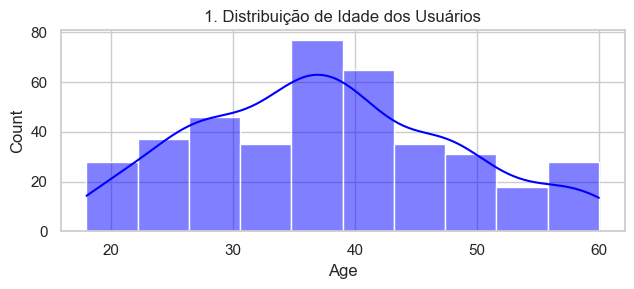

In [24]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16,12))

plt.subplot(4, 2, 1)
sns.histplot(df['Age'], kde=True, color='blue')
plt.title('1. Distribuição de Idade dos Usuários')

Text(0.5, 1.0, '2. Dispersão de Salários Estimados')

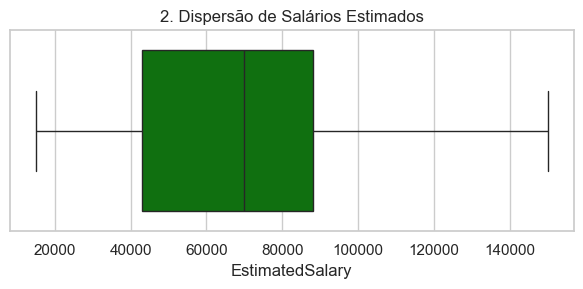

In [25]:
plt.figure(figsize=(16,12))
plt.subplot(4, 2, 2)
sns.boxplot(x=df['EstimatedSalary'], color='green')
plt.title('2. Dispersão de Salários Estimados')

Text(0.5, 1.0, '3. Proporção: Não Comprou (0) vs Comprou (1)')

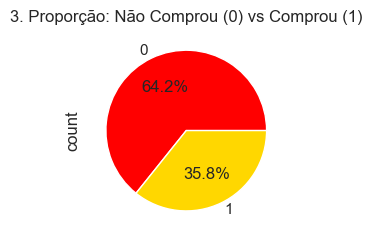

In [26]:
plt.figure(figsize=(16,12))
plt.subplot(4, 2, 3)
df['Purchased'].value_counts().plot.pie(autopct='%1.1f%%', colors=['red', 'gold'])
plt.title('3. Proporção: Não Comprou (0) vs Comprou (1)')

Text(0.5, 1.0, '4. Idade vs Salário por Decisão de Compra')

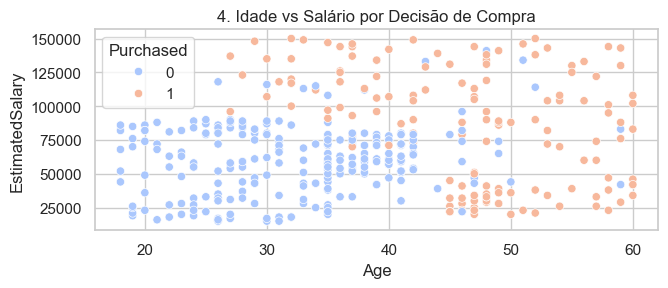

In [27]:
plt.figure(figsize=(16,12))

plt.subplot(4, 2, 4)
sns.scatterplot(data=df, x='Age', y='EstimatedSalary', hue='Purchased', palette='coolwarm')
plt.title('4. Idade vs Salário por Decisão de Compra')

Text(0.5, 1.0, '5. Média Salarial por Gênero')

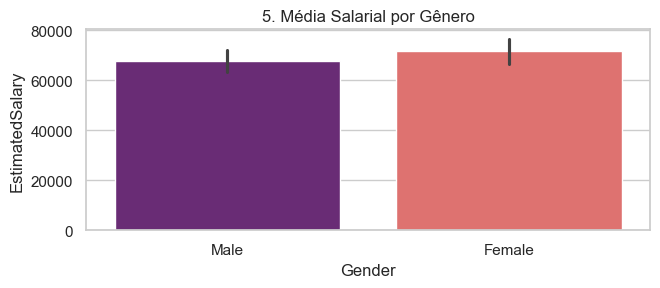

In [28]:
plt.figure(figsize=(16,12))
plt.subplot(4, 2, 5)
sns.barplot(data=df, x='Gender', y='EstimatedSalary', hue='Gender', palette='magma', legend=False)
plt.title('5. Média Salarial por Gênero')

C:\Users\lucas\AppData\Local\Temp\ipykernel_7748\3206685233.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='Purchased', y='Age', palette='Set2')


Text(0.5, 1.0, '6. Densidade de Idade por Compra')

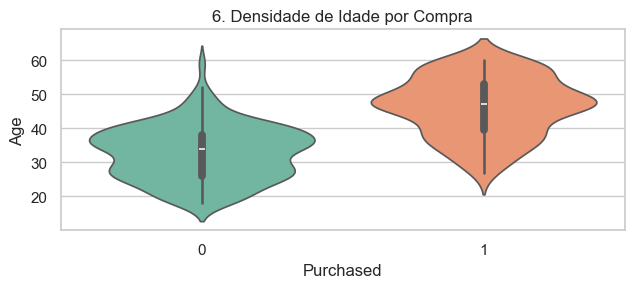

In [29]:
plt.figure(figsize=(16,12))
plt.subplot(4, 2, 6)
sns.violinplot(data=df, x='Purchased', y='Age', palette='Set2')
plt.title('6. Densidade de Idade por Compra')

Text(0.5, 1.0, '7. Correlação entre as Variáveis')

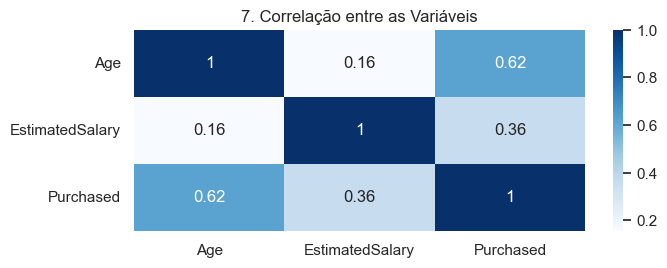

In [30]:
plt.figure(figsize=(16,12))
plt.subplot(4, 2, 7)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues')
plt.title('7. Correlação entre as Variáveis')

Text(0.5, 1.0, '8. Volume de Compras por Gênero')

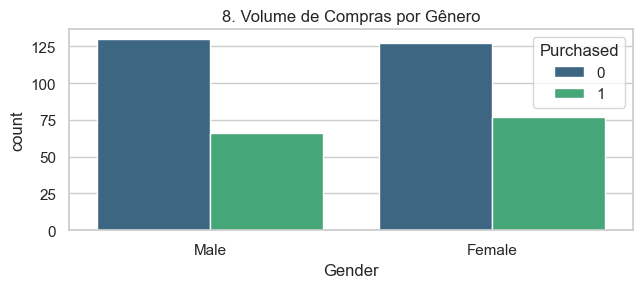

In [31]:
plt.figure(figsize=(16,12))
plt.subplot(4, 2, 8)
sns.countplot(data=df, x='Gender', hue='Purchased', palette='viridis')
plt.title('8. Volume de Compras por Gênero')

## 5. Feature Engineering

Transformando a variável categória 'Gender' em dados numéricos para que o algoritmo de Machine Learning possa processar a informação corretamente.

In [32]:
df['Gender_n'] = df['Gender'].map({'Male': 1, 'Female': 0})

## 6. Modelagem Preditiva e Machine Learning

Dividindo os dados em conjunto de treino e teste. Para classificar os usuários utilizei a Regressão Logística.

In [33]:
X = df[['Age', 'EstimatedSalary', 'Gender_n']]
y = df['Purchased']

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

modelo = LogisticRegression(max_iter=1000)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)

## 7. Avaliação de Modelo

Avaliando o desempenho do modelo utilizando a **Matriz de Confusão**, além das métricas de Precisã, Recall e F1-Score.

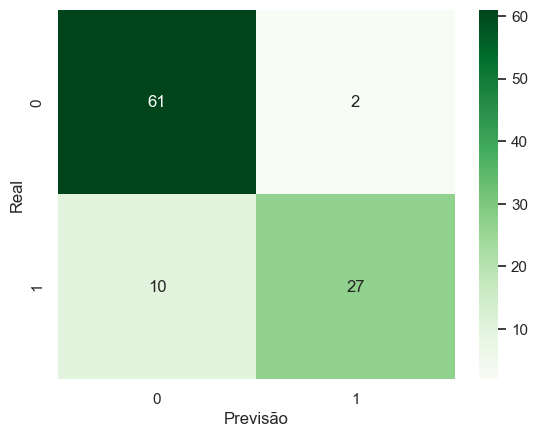


--- RELATÓRIO DE CLASSIFICAÇÃO ---
              precision    recall  f1-score   support

           0       0.86      0.97      0.91        63
           1       0.93      0.73      0.82        37

    accuracy                           0.88       100
   macro avg       0.90      0.85      0.86       100
weighted avg       0.89      0.88      0.88       100



In [35]:
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Previsão')
plt.ylabel('Real')
plt.show()

print("\n--- RELATÓRIO DE CLASSIFICAÇÃO ---")
print(classification_report(y_test, y_pred))